# Debugging PyTorch Models


## Setup

In [1]:
import torch

## TensorBoard

According to ChatGPT, TensorBoard is depricated.

TensorBoard example: https://github.com/falloutdurham/beginners-pytorch-deep-learning/blob/master/chapter7/tensorboard-example.py

## PyTorch Hooks

In [11]:
import torchvision.models as models

def print_hook(model, input, output):
  print(f"Shape of input: {input[0].shape}")

model = models.resnet18()
hook_ref = model.fc.register_forward_hook(print_hook) # fc - final fully connected layer
model(torch.rand(1,3,224,224))

hook_ref.remove()
pred = model(torch.rand(1,3,224,224))

Shape of input: torch.Size([1, 512])


## Class Activation Mapping - CAM

CAM is a technique for vis the activations of a network after it has classified an incoming tensor:

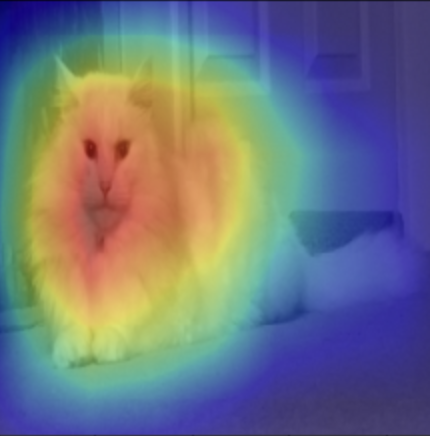

CAM Example: https://github.com/falloutdurham/beginners-pytorch-deep-learning/blob/master/chapter7/cam.ipynb

## Flame Graphs

shows stacktrace in a Flame graph form

### Bad random

Example of py-spy usage to generate stacktraces into flame graphs:
- with bad random (on CPU): https://github.com/falloutdurham/beginners-pytorch-deep-learning/blob/master/chapter7/flame_graphs/bad_random.py and to call https://github.com/falloutdurham/beginners-pytorch-deep-learning/blob/master/chapter7/flame_graphs/create_flame_graph_bad_random.sh
- with good random (on GPU): https://github.com/falloutdurham/beginners-pytorch-deep-learning/blob/master/chapter7/flame_graphs/good_random.py and to call https://github.com/falloutdurham/beginners-pytorch-deep-learning/blob/master/chapter7/flame_graphs/create_flame_graph_good_random.sh

## Debugging GPU Issues

### check GPU

In [8]:
!nvidia-smi

Wed Apr  8 12:47:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P0             27W /   70W |     169MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Gradient Checkpoint

In [11]:
import torch.nn as nn
from torch.utils.checkpoint import checkpoint_sequential

class CheckpointedAlexNet(nn.Module):

    def __init__(self, num_classes=1000, chunks=2):
        super(CheckpointedAlexNet, self).__init__()
        self.chunks = chunks
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = checkpoint_sequential(self.features, self.chunks, x)
        x = self.avgpool(x)
        x = x.view(x.size(0), 256*6*6)
        x = self.classifier(x)
        return x


## PyTorch Profiler

ChatGPT says best practice is **torch.profiler**

Best for: performance bugs, GPU stalls, memory issues

Tracks CPU + CUDA + memory + ops

Produces traces → view in Perfetto / Chrome tracing


In [12]:
import torch
import torchvision.models as models
from torch.profiler import profile, record_function, ProfilerActivity

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18().to(device)
model.eval()

# dummy input
inputs = torch.randn(32, 3, 224, 224).to(device)

with profile(
    activities=[
        ProfilerActivity.CPU,
        ProfilerActivity.CUDA
    ],
    record_shapes=True,
    profile_memory=True,
    with_stack=True
) as prof:

    with record_function("model_inference"):
        model(inputs)

# print summary
print(
    prof.key_averages()
        .table(sort_by="cuda_time_total", row_limit=10)
)

/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                        model_inference         0.00%       0.000us         0.00%       0.000us       0.000us     325.127ms       954.26%     325.127ms     162.564ms           0 B           0 B           0 B           0 